In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  Underwater Anomaly Detection — Two-Stage PointNet Pipeline (T4 GPU)   ║
# ║                                                                        ║
# ║  Stage 1 — Binary PointNet                                            ║
# ║    Input : non-seafloor point clusters                                 ║
# ║    Output: anomaly vs not_anomaly                                      ║
# ║                                                                        ║
# ║  Stage 2 — 3-Class PointNet (from previous notebook)                  ║
# ║    Input : clusters flagged as anomaly by Stage 1                      ║
# ║    Output: cube_anomaly | sphere_anomaly | boat_anomaly               ║
# ║                                                                        ║
# ║  Training : local patches (both stages)                                ║
# ║  Inference: DBSCAN object clusters fed through both stages             ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# ── CELL 1: Install dependencies ─────────────────────────────────────────────
!pip install torch torchvision plotly scikit-learn pandas numpy matplotlib tqdm joblib --quiet

# ── CELL 2: Mount Google Drive ────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── CELL 3: Imports ───────────────────────────────────────────────────────────
import re, json, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
from tqdm import tqdm
from copy import deepcopy

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split
from sklearn.cluster import DBSCAN
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              RocCurveDisplay)
import joblib

warnings.filterwarnings("ignore")


# ── Timing utilities (used throughout training + inference) ───────────────────

class CUDATimer:
    """
    Measures GPU wall-clock time using CUDA events when a GPU is available,
    falling back to time.perf_counter() on CPU.

    CUDA events synchronise the stream so you measure actual kernel execution
    time — not just Python dispatch time, which is always misleadingly fast.

    Usage:
        with CUDATimer() as t:
            output = model(input)
        print(f"{t.ms:.2f} ms")
    """
    def __init__(self):
        self.use_cuda = torch.cuda.is_available()
        self.ms = 0.0

    def __enter__(self):
        if self.use_cuda:
            self._s = torch.cuda.Event(enable_timing=True)
            self._e = torch.cuda.Event(enable_timing=True)
            torch.cuda.synchronize()
            self._s.record()
        else:
            self._t = time.perf_counter()
        return self

    def __exit__(self, *_):
        if self.use_cuda:
            self._e.record()
            torch.cuda.synchronize()
            self.ms = self._s.elapsed_time(self._e)
        else:
            self.ms = (time.perf_counter() - self._t) * 1000


def _warmup(model1, model2, n: int = 10):
    """Silent forward passes to trigger CUDA JIT before any timed run."""
    dummy = torch.randn(1, NUM_POINTS, 3).to(DEVICE)
    model1.eval(); model2.eval()
    with torch.no_grad():
        for _ in range(n):
            out = model1(dummy)
            if out.argmax(1).item() == 1:
                model2(dummy)
    if torch.cuda.is_available():
        torch.cuda.synchronize()


Mounted at /content/drive


In [ ]:
# ── CELL 4: Configuration ─────────────────────────────────────────────────────
DATA_DIR   = "/content/drive/Shareddrives/DAEN Capstone/Data/Training Data/labeled_point_clouds_csv"   # ← change this
OUTPUT_DIR = "/content/drive/Shareddrives/DAEN Capstone/Models"      # ← change this

# ── Class definitions (original labels) ──────────────────────────────────────
SEAFLOOR_CLASS  = {0}
NATURAL_CLASSES = {4, 5, 6}        # coral, rock, wildlife
ANOMALY_CLASSES = {1, 2, 3}        # cube, sphere, boat
NON_SEAFLOOR    = NATURAL_CLASSES | ANOMALY_CLASSES   # what Stage 1 sees

# Stage 1 binary labels
BINARY_LABEL = {
    **{c: 0 for c in NATURAL_CLASSES},   # 0 = not_anomaly
    **{c: 1 for c in ANOMALY_CLASSES},   # 1 = anomaly
}
BINARY_NAMES = {0: "not_anomaly", 1: "anomaly"}

# Stage 2 3-class labels (re-mapped to 0-indexed)
CLASS_REMAP     = {1: 0, 2: 1, 3: 2}
CLASS_REMAP_INV = {0: 1, 1: 2, 2: 3}
ANOMALY_NAMES   = {0: "cube_anomaly", 1: "sphere_anomaly", 2: "boat_anomaly"}
NUM_ANOMALY_CLS = 3

# Colours for visualisation
STAGE1_COLOURS = {0: "steelblue", 1: "red"}
STAGE2_COLOURS = {0: "red", 1: "orange", 2: "magenta"}
NATURAL_COLOUR = "steelblue"

# ── PointNet hyperparameters ──────────────────────────────────────────────────
NUM_POINTS        = 1024
PATCH_RADIUS      = 1.5      # metres
MIN_PATCH_POINTS  = 32

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE           = 32
NUM_EPOCHS           = 80
LEARNING_RATE        = 1e-3
WEIGHT_DECAY         = 1e-4
EARLY_STOP_PATIENCE  = 12
LABEL_SMOOTHING      = 0.1

# ── Data ──────────────────────────────────────────────────────────────────────
MAX_PATCHES_PER_SCENE = 150
TEST_SIZE             = 0.2
RANDOM_SEED           = 42

# ── DBSCAN (inference clustering) ────────────────────────────────────────────
DBSCAN_EPS      = 0.5
DBSCAN_MIN_PTS  = 10

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"       GPU: {torch.cuda.get_device_name(0)}")

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)


# ═════════════════════════════════════════════════════════════════════════════
# CELL 5: Scene discovery + loading
# ═════════════════════════════════════════════════════════════════════════════

def discover_scenes(data_dir: str) -> list[dict]:
    data_path        = Path(data_dir)
    anomaly_files    = set(data_path.glob("scene_*_anomaly_labeled.csv"))
    no_anomaly_files = set(data_path.glob("scene_*_no_anomaly_labeled.csv"))
    anomaly_files   -= no_anomaly_files

    scenes = []
    for f in anomaly_files:
        scenes.append({"path": f, "has_anomaly": True})
    for f in no_anomaly_files:
        scenes.append({"path": f, "has_anomaly": False})

    def scene_num(s):
        m = re.search(r"scene_(\d+)", s["path"].stem)
        return int(m.group(1)) if m else 0

    scenes = sorted(scenes, key=scene_num)
    n_anom = sum(s["has_anomaly"] for s in scenes)
    print(f"[INFO] Found {len(scenes)} scenes "
          f"({n_anom} with anomaly | {len(scenes)-n_anom} without)")
    return scenes


def load_non_seafloor(scene: dict) -> pd.DataFrame | None:
    """
    Load scene CSV and return only NON-SEAFLOOR points.
    Class 0 (seafloor) is dropped. Everything else is kept.
    Returns None if scene has no non-seafloor points at all.
    """
    df = pd.read_csv(scene["path"])
    df.columns = df.columns.str.lower()

    required = {"x", "y", "z", "class"}
    if missing := required - set(df.columns):
        raise ValueError(f"Missing columns {missing} in {scene['path'].name}")

    df = df[~df["class"].isin(SEAFLOOR_CLASS)].reset_index(drop=True)
    if len(df) == 0:
        return None

    # Add binary label (Stage 1) and anomaly sub-label (Stage 2)
    df["binary_label"] = df["class"].map(BINARY_LABEL)
    df["anomaly_label"] = df["class"].map(CLASS_REMAP)   # NaN for natural objs
    return df


# ═════════════════════════════════════════════════════════════════════════════
# CELL 6: Patch extraction — shared by both stages
# ═════════════════════════════════════════════════════════════════════════════

def _normalise(xyz: np.ndarray) -> np.ndarray:
    """Centre and scale point cloud to unit sphere."""
    xyz = xyz - xyz.mean(axis=0)
    scale = np.max(np.linalg.norm(xyz, axis=1)) + 1e-8
    return xyz / scale


def extract_patches_stage1(df: pd.DataFrame,
                            n_patches: int = MAX_PATCHES_PER_SCENE,
                            seed: int = RANDOM_SEED) -> list[dict]:
    """
    Extract patches for Stage 1 binary classifier.
    Anchors are sampled from ALL non-seafloor points so the model sees
    both natural objects and anomalies in their spatial context.
    Patches near class boundaries will contain mixed points — the majority
    binary label is used.
    """
    rng = np.random.default_rng(seed)
    xyz = df[["x","y","z"]].values.astype(np.float32)
    bin_lbl = df["binary_label"].values.astype(np.int64)

    # Stratified anchor sampling: equal chance of anomaly / natural anchors
    anom_idx    = np.where(bin_lbl == 1)[0]
    natural_idx = np.where(bin_lbl == 0)[0]
    n_each      = n_patches // 2

    anchors = []
    if len(anom_idx) > 0:
        anchors.append(rng.choice(anom_idx,
                                   min(n_each, len(anom_idx)), replace=False))
    if len(natural_idx) > 0:
        anchors.append(rng.choice(natural_idx,
                                   min(n_each, len(natural_idx)), replace=False))
    if not anchors:
        return []
    anchor_idx = np.concatenate(anchors)

    patches = []
    for ai in anchor_idx:
        centre = xyz[ai]
        within = np.where(np.linalg.norm(xyz - centre, axis=1)
                          <= PATCH_RADIUS)[0]
        if len(within) < MIN_PATCH_POINTS:
            continue

        chosen = (rng.choice(within, NUM_POINTS, replace=False)
                  if len(within) >= NUM_POINTS
                  else rng.choice(within, NUM_POINTS, replace=True))

        patch_xyz = _normalise(xyz[chosen].copy())
        patch_lbl = bin_lbl[chosen]
        label     = int(np.bincount(patch_lbl, minlength=2).argmax())

        patches.append({"xyz": patch_xyz, "label": label, "centroid": centre})
    return patches


def extract_patches_stage2(df: pd.DataFrame,
                            n_patches: int = MAX_PATCHES_PER_SCENE,
                            seed: int = RANDOM_SEED) -> list[dict]:
    """
    Extract patches for Stage 2 — ONLY from anomaly points.
    Natural object points are excluded so Stage 2 never sees them.
    """
    rng     = np.random.default_rng(seed)
    anom_df = df[df["binary_label"] == 1].reset_index(drop=True)
    if len(anom_df) == 0:
        return []

    xyz     = anom_df[["x","y","z"]].values.astype(np.float32)
    lbl     = anom_df["anomaly_label"].values.astype(np.int64)

    n_anchors  = min(len(xyz), n_patches)
    anchor_idx = rng.choice(len(xyz), n_anchors, replace=False)

    patches = []
    for ai in anchor_idx:
        centre = xyz[ai]
        within = np.where(np.linalg.norm(xyz - centre, axis=1)
                          <= PATCH_RADIUS)[0]
        if len(within) < MIN_PATCH_POINTS:
            continue

        chosen = (rng.choice(within, NUM_POINTS, replace=False)
                  if len(within) >= NUM_POINTS
                  else rng.choice(within, NUM_POINTS, replace=True))

        patch_xyz = _normalise(xyz[chosen].copy())
        patch_lbl = lbl[chosen]
        label     = int(np.bincount(patch_lbl, minlength=NUM_ANOMALY_CLS).argmax())

        patches.append({"xyz": patch_xyz, "label": label, "centroid": centre})
    return patches


# ═════════════════════════════════════════════════════════════════════════════
# CELL 7: Inference — DBSCAN cluster extraction
# ═════════════════════════════════════════════════════════════════════════════

def extract_clusters(df: pd.DataFrame,
                     seed: int = RANDOM_SEED) -> list[dict]:
    """
    Group non-seafloor points into spatial clusters using DBSCAN.
    Each cluster = one object cloud that will be fed through Stage 1 → Stage 2.

    Returns list of dicts with:
        xyz          : (N,3) normalised cloud
        true_binary  : ground truth binary label (majority vote)
        true_anomaly : ground truth anomaly sub-class (or -1 if natural)
        centroid     : world-space centre
        n_points     : original cluster size
        extents      : (3,) XYZ bounding box extents
        cluster_id   : DBSCAN cluster index
        raw_xyz      : un-normalised cloud (for world-space visualisation)
    """
    rng = np.random.default_rng(seed)
    xyz     = df[["x","y","z"]].values.astype(np.float32)
    bin_lbl = df["binary_label"].values.astype(np.int64)
    anom_lbl = df["anomaly_label"].values  # may contain NaN for natural

    db   = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_PTS, n_jobs=-1)
    cids = db.fit_predict(xyz)

    clusters = []
    for cid in sorted(set(cids)):
        if cid < 0:
            continue

        mask      = cids == cid
        obj_xyz   = xyz[mask]
        obj_bin   = bin_lbl[mask]
        obj_anom  = anom_lbl[mask]

        if len(obj_xyz) < 8:
            continue

        # Sample to fixed size
        n = len(obj_xyz)
        idx = (rng.choice(n, NUM_POINTS, replace=False) if n >= NUM_POINTS
               else rng.choice(n, NUM_POINTS, replace=True))

        raw_cloud = obj_xyz[idx].copy()
        cloud     = _normalise(raw_cloud.copy())

        # Ground truth labels via majority vote
        true_binary = int(np.bincount(obj_bin, minlength=2).argmax())
        valid_anom  = obj_anom[~np.isnan(obj_anom)].astype(int)
        true_anomaly = (int(np.bincount(valid_anom,
                                         minlength=NUM_ANOMALY_CLS).argmax())
                        if len(valid_anom) > 0 else -1)

        clusters.append({
            "xyz":          cloud,
            "raw_xyz":      raw_cloud,
            "true_binary":  true_binary,
            "true_anomaly": true_anomaly,
            "centroid":     obj_xyz.mean(axis=0),
            "n_points":     n,
            "extents":      obj_xyz.max(axis=0) - obj_xyz.min(axis=0),
            "cluster_id":   cid,
            # Stage predictions filled in later
            "pred_binary":  None,
            "pred_anomaly": None,
            "binary_conf":  None,
            "anomaly_conf": None,
            "final_label":  None,   # combined string label
        })
    return clusters


# ═════════════════════════════════════════════════════════════════════════════
# CELL 8: Dataset
# ═════════════════════════════════════════════════════════════════════════════

class PatchDataset(Dataset):
    def __init__(self, patches: list[dict], augment: bool = False):
        self.patches = patches
        self.augment = augment

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        p   = self.patches[idx]
        xyz = torch.from_numpy(p["xyz"].copy()).float()
        lbl = torch.tensor(p["label"], dtype=torch.long)

        if self.augment:
            # Random yaw rotation
            a = torch.empty(1).uniform_(0, 2 * torch.pi)
            c, s = torch.cos(a), torch.sin(a)
            R = torch.tensor([[c,-s,0],[s,c,0],[0,0,1]],
                              dtype=torch.float).squeeze()
            xyz = xyz @ R.T
            xyz += torch.randn_like(xyz) * 0.01
            xyz  = torch.clamp(xyz, -1.0, 1.0)
            xyz *= torch.empty(1).uniform_(0.9, 1.1)

        return xyz, lbl


def make_sampler(patches: list[dict], n_classes: int) -> WeightedRandomSampler:
    labels  = [p["label"] for p in patches]
    counts  = np.bincount(labels, minlength=n_classes).astype(float)
    w_class = 1.0 / np.maximum(counts, 1)
    weights = [w_class[l] for l in labels]
    return WeightedRandomSampler(weights, len(weights), replacement=True)


# ═════════════════════════════════════════════════════════════════════════════
# CELL 9: PointNet architecture (shared by both stages, different head sizes)
# ═════════════════════════════════════════════════════════════════════════════

class TNet(nn.Module):
    def __init__(self, k: int = 3):
        super().__init__()
        self.k   = k
        self.mlp = nn.Sequential(
            nn.Linear(k,   64),  nn.BatchNorm1d(64),   nn.ReLU(),
            nn.Linear(64,  128), nn.BatchNorm1d(128),  nn.ReLU(),
            nn.Linear(128, 1024),nn.BatchNorm1d(1024), nn.ReLU(),
        )
        self.fc  = nn.Sequential(
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512,  256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256,  k*k),
        )
        nn.init.zeros_(self.fc[-1].weight)
        nn.init.zeros_(self.fc[-1].bias)

    def forward(self, x):
        B, N, k = x.shape
        h = self.mlp(x.view(B*N, k)).view(B, N, 1024).max(1).values
        I = torch.eye(self.k, device=x.device).unsqueeze(0).expand(B,-1,-1)
        return self.fc(h).view(B, self.k, self.k) + I


class PointNet(nn.Module):
    """
    Full PointNet with input + feature T-Nets and a configurable
    classification head. Used identically for both stages — only
    `num_classes` differs (2 for Stage 1, 3 for Stage 2).
    """
    def __init__(self, num_classes: int):
        super().__init__()
        self.input_tnet   = TNet(k=3)
        self.feature_tnet = TNet(k=64)
        self.mlp1 = nn.Sequential(
            nn.Linear(3,  64),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Linear(64, 64),  nn.BatchNorm1d(64),  nn.ReLU(),
        )
        self.mlp2 = nn.Sequential(
            nn.Linear(64,  128), nn.BatchNorm1d(128),  nn.ReLU(),
            nn.Linear(128, 1024),nn.BatchNorm1d(1024), nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512,  256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
        self._feat_T = None

    def forward(self, x):
        B, N, _ = x.shape
        x  = torch.bmm(x, self.input_tnet(x))
        h  = self.mlp1(x.view(B*N, 3)).view(B, N, 64)
        T2 = self.feature_tnet(h)
        h  = torch.bmm(h, T2);  self._feat_T = T2
        h  = self.mlp2(h.view(B*N, 64)).view(B, N, 1024).max(1).values
        return self.head(h)

    def tnet_reg(self, w: float = 1e-3) -> torch.Tensor:
        if self._feat_T is None:
            return torch.tensor(0.0)
        T  = self._feat_T;  B = T.shape[0]
        I  = torch.eye(64, device=T.device).unsqueeze(0).expand(B,-1,-1)
        return w * ((torch.bmm(T, T.transpose(1,2)) - I)**2).sum((1,2)).mean()


# ═════════════════════════════════════════════════════════════════════════════
# CELL 10: Generic training loop (used for both stages)
# ═════════════════════════════════════════════════════════════════════════════

def train_stage(model: PointNet,
                train_patches: list[dict],
                val_patches:   list[dict],
                n_classes:     int,
                stage_name:    str,
                ckpt_path:     str) -> dict:

    train_ds = PatchDataset(train_patches, augment=True)
    val_ds   = PatchDataset(val_patches,   augment=False)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                               sampler=make_sampler(train_patches, n_classes),
                               num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE,
                               shuffle=False, num_workers=2, pin_memory=True)

    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    opt       = torch.optim.Adam(model.parameters(),
                                  lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    sched     = torch.optim.lr_scheduler.CosineAnnealingLR(
                    opt, T_max=NUM_EPOCHS, eta_min=1e-5)

    best_acc, patience = 0.0, 0
    history = {"train_loss":[],"val_loss":[],"train_acc":[],"val_acc":[],
               "epoch_train_ms":[], "epoch_val_ms":[], "batch_ms":[]}

    counts = np.bincount([p["label"] for p in train_patches],
                          minlength=n_classes)
    print(f"\n[{stage_name}] Training for {NUM_EPOCHS} epochs …")
    print(f"  Train: {len(train_patches):,} patches | "
          f"Val: {len(val_patches):,} patches")
    print(f"  Class counts: { {i: int(counts[i]) for i in range(n_classes)} }")

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        tl, tc, tt = 0.0, 0, 0
        batch_times = []
        with CUDATimer() as epoch_train_t:
            for xyz, lbl in train_loader:
                xyz, lbl = xyz.to(DEVICE), lbl.to(DEVICE)
                with CUDATimer() as batch_t:
                    opt.zero_grad()
                    logits = model(xyz)
                    loss   = criterion(logits, lbl) + model.tnet_reg()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt.step()
                batch_times.append(batch_t.ms)
                tl += loss.item() * len(lbl)
                tc += (logits.argmax(1) == lbl).sum().item()
                tt += len(lbl)

        model.eval()
        vl, vc, vt = 0.0, 0, 0
        with CUDATimer() as epoch_val_t:
            with torch.no_grad():
                for xyz, lbl in val_loader:
                    xyz, lbl = xyz.to(DEVICE), lbl.to(DEVICE)
                    logits   = model(xyz)
                    loss     = criterion(logits, lbl)
                    vl += loss.item() * len(lbl)
                    vc += (logits.argmax(1) == lbl).sum().item()
                    vt += len(lbl)

        tr_loss, vl_loss = tl/tt, vl/vt
        tr_acc,  vl_acc  = tc/tt, vc/vt
        sched.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)
        history["epoch_train_ms"].append(epoch_train_t.ms)
        history["epoch_val_ms"].append(epoch_val_t.ms)
        history["batch_ms"].append(float(np.mean(batch_times)))

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Ep {epoch:3d}/{NUM_EPOCHS} | "
                  f"Loss {tr_loss:.4f}/{vl_loss:.4f} | "
                  f"Acc {tr_acc:.3f}/{vl_acc:.3f} | "
                  f"Train {epoch_train_t.ms:.0f}ms  Val {epoch_val_t.ms:.0f}ms  "
                  f"Batch avg {np.mean(batch_times):.1f}ms")

        if vl_acc > best_acc:
            best_acc, patience = vl_acc, 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            patience += 1
            if patience >= EARLY_STOP_PATIENCE:
                print(f"  Early stop at epoch {epoch}")
                break

    model.load_state_dict(torch.load(ckpt_path))
    total_train_s = sum(history["epoch_train_ms"]) / 1000
    avg_epoch_ms  = np.mean(history["epoch_train_ms"])
    avg_batch_ms  = np.mean(history["batch_ms"])
    n_epochs_run  = len(history["epoch_train_ms"])
    print(f"  Best val acc   : {best_acc:.4f}")
    print(f"  ── Training time ──────────────────────────────────")
    print(f"  Total train time : {total_train_s:.1f}s  "
          f"over {n_epochs_run} epochs")
    print(f"  Avg epoch time   : {avg_epoch_ms:.0f}ms  "
          f"(train) + {np.mean(history['epoch_val_ms']):.0f}ms (val)")
    print(f"  Avg batch time   : {avg_batch_ms:.2f}ms  "
          f"({BATCH_SIZE} patches/batch → "
          f"{1000*BATCH_SIZE/avg_batch_ms:.0f} patches/sec)")
    return history


# ═════════════════════════════════════════════════════════════════════════════
# CELL 11: Evaluation helpers
# ═════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def predict_patches(model: PointNet,
                    patches: list[dict]) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    ds     = PatchDataset(patches, augment=False)
    loader = DataLoader(ds, batch_size=64, shuffle=False,
                        num_workers=2, pin_memory=True)
    preds, labels = [], []
    for xyz, lbl in loader:
        logits = model(xyz.to(DEVICE))
        preds.extend(logits.argmax(1).cpu().numpy())
        labels.extend(lbl.numpy())
    return np.array(preds), np.array(labels)


def plot_training(h1: dict, h2: dict):
    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    for row, (h, title) in enumerate([(h1, "Stage 1 — Binary"),
                                       (h2, "Stage 2 — Anomaly type")]):
        axes[row,0].plot(h["train_loss"], label="Train", color="steelblue")
        axes[row,0].plot(h["val_loss"],   label="Val",   color="tomato")
        axes[row,0].set_title(f"{title} — Loss")
        axes[row,0].legend(); axes[row,0].set_xlabel("Epoch")

        axes[row,1].plot(h["train_acc"], label="Train", color="steelblue")
        axes[row,1].plot(h["val_acc"],   label="Val",   color="tomato")
        axes[row,1].set_title(f"{title} — Accuracy")
        axes[row,1].legend(); axes[row,1].set_xlabel("Epoch")

    # Bottom row: epoch timing for both stages on same axes
    ax_ep = axes[2, 0]
    ax_ep.plot(h1["epoch_train_ms"], label="S1 train", color="steelblue")
    ax_ep.plot(h1["epoch_val_ms"],   label="S1 val",   color="steelblue",
               linestyle="--", alpha=0.6)
    ax_ep.plot(h2["epoch_train_ms"], label="S2 train", color="tomato")
    ax_ep.plot(h2["epoch_val_ms"],   label="S2 val",   color="tomato",
               linestyle="--", alpha=0.6)
    ax_ep.set_title("Epoch time (ms)")
    ax_ep.set_xlabel("Epoch"); ax_ep.set_ylabel("ms")
    ax_ep.legend(fontsize=8)

    ax_bt = axes[2, 1]
    ax_bt.plot(h1["batch_ms"], label="Stage 1", color="steelblue")
    ax_bt.plot(h2["batch_ms"], label="Stage 2", color="tomato")
    ax_bt.set_title("Avg batch time (ms)")
    ax_bt.set_xlabel("Epoch"); ax_bt.set_ylabel("ms")
    ax_bt.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150,
                bbox_inches="tight")
    plt.show()
    print(f"[INFO] Training curves → {OUTPUT_DIR}/training_curves.png")


def evaluate_stage1(model1, val1_patches):
    preds, labels = predict_patches(model1, val1_patches)
    print("\n" + "═"*55)
    print("STAGE 1 — Binary detector (patch level)")
    print("═"*55)
    print(classification_report(labels, preds,
                                  target_names=list(BINARY_NAMES.values()),
                                  zero_division=0))
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(5,4))
    ConfusionMatrixDisplay(cm, display_labels=list(BINARY_NAMES.values())
                           ).plot(ax=ax, colorbar=False)
    ax.set_title("Stage 1 — Confusion matrix")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/stage1_cm.png", dpi=150)
    plt.show()


def evaluate_stage2(model2, val2_patches):
    preds, labels = predict_patches(model2, val2_patches)
    print("\n" + "═"*55)
    print("STAGE 2 — Anomaly classifier (patch level)")
    print("═"*55)
    print(classification_report(labels, preds,
                                  target_names=list(ANOMALY_NAMES.values()),
                                  zero_division=0))
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(5,4))
    ConfusionMatrixDisplay(cm, display_labels=list(ANOMALY_NAMES.values())
                           ).plot(ax=ax, colorbar=False)
    ax.set_title("Stage 2 — Confusion matrix")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/stage2_cm.png", dpi=150)
    plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# CELL 12: Two-stage inference on DBSCAN clusters
# ═════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def run_pipeline(clusters:  list[dict],
                 model1:    PointNet,
                 model2:    PointNet) -> tuple[list[dict], dict]:
    """
    Feed each cluster through both stages:
        Stage 1: is this cluster an anomaly or not?
        Stage 2: if anomaly → which type (cube / sphere / boat)?

    Returns (results, timing) where timing is a dict of ms breakdowns.
    """
    if not clusters:
        return [], {}

    model1.eval();  model2.eval()
    results = deepcopy(clusters)

    timing = {"t_stage1_ms": 0.0, "t_stage2_ms": 0.0,
              "n_clusters": len(clusters), "n_anomaly_clusters": 0}

    # ── Stage 1: binary classification ───────────────────────────────────────
    batch = torch.stack([torch.from_numpy(c["xyz"]).float()
                          for c in clusters]).to(DEVICE)

    with CUDATimer() as t_s1:
        logits1 = model1(batch)
        proba1  = F.softmax(logits1, dim=1)
        preds1  = proba1.argmax(dim=1)

    timing["t_stage1_ms"] = t_s1.ms

    for i, r in enumerate(results):
        r["pred_binary"] = int(preds1[i])
        r["binary_conf"] = float(proba1[i, preds1[i]])

    # ── Stage 2: anomaly sub-classification ──────────────────────────────────
    anom_idx = [i for i, r in enumerate(results) if r["pred_binary"] == 1]
    timing["n_anomaly_clusters"] = len(anom_idx)

    if anom_idx:
        anom_batch = torch.stack(
            [torch.from_numpy(results[i]["xyz"]).float()
             for i in anom_idx]).to(DEVICE)

        with CUDATimer() as t_s2:
            logits2 = model2(anom_batch)
            proba2  = F.softmax(logits2, dim=1)
            preds2  = proba2.argmax(dim=1)

        timing["t_stage2_ms"] = t_s2.ms

        for j, i in enumerate(anom_idx):
            results[i]["pred_anomaly"] = int(preds2[j])
            results[i]["anomaly_conf"] = float(proba2[j, preds2[j]])

    timing["t_model_ms"] = timing["t_stage1_ms"] + timing["t_stage2_ms"]

    # ── Assign final readable label ───────────────────────────────────────────
    for r in results:
        if r["pred_binary"] == 0:
            r["final_label"] = "not_anomaly"
        else:
            r["final_label"] = ANOMALY_NAMES.get(r["pred_anomaly"], "anomaly")

    return results, timing


def print_pipeline_summary(results: list[dict]):
    if not results:
        print("[INFO] No clusters to display.")
        return

    print(f"\n[PIPELINE RESULTS] {len(results)} clusters")
    print(f"  {'ID':>3}  {'True':>16}  {'Final pred':>16}  "
          f"{'S1':>5}  {'S2':>5}  {'Points':>7}  {'OK'}")
    print("  " + "─"*70)

    correct = 0
    for r in results:
        # Determine true final label string for comparison
        if r["true_binary"] == 0:
            true_str = "not_anomaly"
        else:
            true_str = ANOMALY_NAMES.get(r["true_anomaly"], "anomaly")

        match    = "✓" if r["final_label"] == true_str else "✗"
        if r["final_label"] == true_str:
            correct += 1
        s1_conf  = f"{r['binary_conf']:.2f}" if r["binary_conf"] else "-"
        s2_conf  = (f"{r['anomaly_conf']:.2f}"
                    if r["anomaly_conf"] is not None else "-")

        print(f"  {r['cluster_id']:>3}  {true_str:>16}  "
              f"{r['final_label']:>16}  {s1_conf:>5}  {s2_conf:>5}  "
              f"{r['n_points']:>7,}  {match}")

    acc = correct / len(results)
    print(f"\n  End-to-end accuracy: {correct}/{len(results)} = {acc:.3f}")


# ═════════════════════════════════════════════════════════════════════════════
# CELL 13: 3D Visualisation
# ═════════════════════════════════════════════════════════════════════════════

# Colour map for final labels
FINAL_COLOURS = {
    "not_anomaly":    "steelblue",
    "cube_anomaly":   "red",
    "sphere_anomaly": "orange",
    "boat_anomaly":   "magenta",
}

def _sub(xyz, *arrs, n=25_000):
    if len(xyz) <= n:
        return xyz, *arrs
    idx = np.sort(np.random.choice(len(xyz), n, replace=False))
    return xyz[idx], *(a[idx] for a in arrs)


def visualise_scene(scene_index_or_name,
                     model1: PointNet,
                     model2: PointNet,
                     mode:   str  = "pipeline",
                     plotly: bool = True,
                     mpl:    bool = True):
    """
    Visualise a scene through the full two-stage pipeline.

    mode options:
        'pipeline'    — each cluster coloured by final predicted label
                        (not_anomaly=blue, cube=red, sphere=orange, boat=magenta)
        'stage1'      — colour by Stage 1 binary prediction only
        'ground_truth'— colour by true label
        'comparison'  — side-by-side pipeline prediction vs ground truth
        'objects'     — one trace per cluster with hover showing both stage scores

    Args:
        scene_index_or_name : int index into `scenes` list, or scene name str
    """
    # Resolve scene
    if isinstance(scene_index_or_name, int):
        scene = scenes[scene_index_or_name]
    else:
        matches = [s for s in scenes
                   if scene_index_or_name in s["path"].stem]
        if not matches:
            raise ValueError(f"Scene '{scene_index_or_name}' not found.")
        scene = matches[0]

    print(f"[INFO] Visualising: {scene['path'].stem}  mode='{mode}'")

    df = load_non_seafloor(scene)
    if df is None:
        print("[WARN] No non-seafloor points in this scene.")
        return

    clusters = extract_clusters(df)
    if not clusters:
        print("[WARN] DBSCAN found no clusters.")
        return

    results, _ = run_pipeline(clusters, model1, model2)
    print_pipeline_summary(results)

    # Build per-point arrays by mapping each point to its nearest cluster
    xyz_all = df[["x","y","z"]].values.astype(np.float32)
    centroids = np.array([r["centroid"] for r in results])  # (K, 3)
    diff      = xyz_all[:,None,:] - centroids[None,:,:]
    nearest   = np.linalg.norm(diff, axis=2).argmin(axis=1)

    # Per-point final predicted label, stage1 pred, true binary
    point_final  = np.array([results[i]["final_label"]   for i in nearest])
    point_s1     = np.array([results[i]["pred_binary"]   for i in nearest])
    point_true_b = df["binary_label"].values.astype(int)
    point_true_a = df["anomaly_label"].values  # NaN for naturals

    # True final label per point
    def true_label_str(bin_l, anom_l):
        if bin_l == 0:
            return "not_anomaly"
        return ANOMALY_NAMES.get(int(anom_l) if not np.isnan(anom_l) else -1,
                                  "anomaly")

    point_true_final = np.array([
        true_label_str(b, a)
        for b, a in zip(point_true_b, point_true_a)])

    cam      = dict(eye=dict(x=1.5, y=1.5, z=0.8))
    scene_ax = dict(
        xaxis_title="X", yaxis_title="Y", zaxis_title="Z",
        bgcolor="rgba(240,240,245,0.8)",
        xaxis=dict(showgrid=True, gridcolor="white"),
        yaxis=dict(showgrid=True, gridcolor="white"),
        zaxis=dict(showgrid=True, gridcolor="white"),
    )
    name = scene["path"].stem

    def label_traces(xyz, labels, suffix=""):
        """One Scatter3d trace per unique label."""
        traces = []
        for lbl, col in FINAL_COLOURS.items():
            mask = labels == lbl
            if not mask.any():
                continue
            size = 1.5 if lbl == "not_anomaly" else 3
            opac = 0.3 if lbl == "not_anomaly" else 0.9
            traces.append(go.Scatter3d(
                x=xyz[mask,0], y=xyz[mask,1], z=xyz[mask,2],
                mode="markers",
                marker=dict(size=size, color=col, opacity=opac),
                name=f"{lbl}{suffix}"))
        return traces

    # ── Plotly ────────────────────────────────────────────────────────────────
    if plotly:
        xyz_s, pf_s, pt_s, ps1_s = _sub(
            xyz_all, point_final, point_true_final, point_s1)

        if mode == "pipeline":
            fig = go.Figure(label_traces(xyz_s, pf_s))
            fig.update_layout(
                title=dict(text=f"{name} — Pipeline predictions", x=0.5),
                scene=dict(**scene_ax, camera=cam),
                height=650, width=900,
                margin=dict(l=0,r=0,t=50,b=0))

        elif mode == "ground_truth":
            fig = go.Figure(label_traces(xyz_s, pt_s, " (true)"))
            fig.update_layout(
                title=dict(text=f"{name} — Ground truth", x=0.5),
                scene=dict(**scene_ax, camera=cam),
                height=650, width=900,
                margin=dict(l=0,r=0,t=50,b=0))

        elif mode == "stage1":
            s1_labels = np.where(ps1_s == 1, "anomaly", "not_anomaly")
            s1_cols   = [STAGE1_COLOURS[int(v=="anomaly")] for v in ps1_s]
            fig = go.Figure(go.Scatter3d(
                x=xyz_s[:,0], y=xyz_s[:,1], z=xyz_s[:,2],
                mode="markers",
                marker=dict(size=np.where(ps1_s==1, 3, 1.5),
                             color=s1_cols, opacity=0.7),
                name="Stage 1"))
            fig.update_layout(
                title=dict(text=f"{name} — Stage 1: binary detection", x=0.5),
                scene=dict(**scene_ax, camera=cam),
                height=650, width=900,
                margin=dict(l=0,r=0,t=50,b=0))

        elif mode == "comparison":
            fig = make_subplots(
                rows=1, cols=2,
                subplot_titles=("Pipeline prediction", "Ground truth"),
                specs=[[{"type":"scatter3d"},{"type":"scatter3d"}]])
            for tr in label_traces(xyz_s, pf_s, " (pred)"):
                fig.add_trace(tr, row=1, col=1)
            for tr in label_traces(xyz_s, pt_s, " (true)"):
                fig.add_trace(tr, row=1, col=2)
            fig.update_layout(
                title=dict(text=f"{name} — Pipeline vs Ground truth", x=0.5),
                scene=scene_ax, scene2=scene_ax,
                height=620, width=1150,
                margin=dict(l=0,r=0,t=50,b=0))

        elif mode == "objects":
            # One trace per cluster, coloured + shaped by correctness
            fig = go.Figure()
            for r in results:
                true_str = ("not_anomaly" if r["true_binary"] == 0
                             else ANOMALY_NAMES.get(r["true_anomaly"], "?"))
                correct  = r["final_label"] == true_str
                col      = FINAL_COLOURS.get(r["final_label"], "gray")
                sym      = "circle" if correct else "cross"
                cloud_w  = r["raw_xyz"] + r["centroid"]
                s2_str   = (ANOMALY_NAMES.get(r["pred_anomaly"], "-")
                             if r["pred_anomaly"] is not None else "-")
                hover    = ([
                    f"Predicted: {r['final_label']}<br>"
                    f"True: {true_str}<br>"
                    f"Stage1 conf: {r['binary_conf']:.3f}<br>"
                    f"Stage2: {s2_str} "
                    f"({r['anomaly_conf']:.3f})<br>"
                    f"Points: {r['n_points']:,}"
                ] * len(cloud_w))
                fig.add_trace(go.Scatter3d(
                    x=cloud_w[:,0], y=cloud_w[:,1], z=cloud_w[:,2],
                    mode="markers",
                    marker=dict(size=2, color=col, opacity=0.85,
                                 symbol=sym),
                    name=f"#{r['cluster_id']} {r['final_label']} "
                         f"({'✓' if correct else '✗'})",
                    text=hover,
                    hovertemplate="%{text}<extra></extra>"))
            fig.update_layout(
                title=dict(
                    text=f"{name} — Objects (● correct  ✗ wrong)", x=0.5),
                scene=dict(**scene_ax, camera=cam),
                height=680, width=960,
                legend=dict(x=0.01, y=0.99,
                             bgcolor="rgba(255,255,255,0.8)"),
                margin=dict(l=0,r=0,t=50,b=0))

        else:
            raise ValueError(
                f"Unknown mode '{mode}'. Choose: pipeline | stage1 | "
                f"ground_truth | comparison | objects")

        fig.show()

    # ── Matplotlib ────────────────────────────────────────────────────────────
    if mpl and mode in ("pipeline", "ground_truth", "comparison"):
        xyz_s, pf_s, pt_s = _sub(xyz_all, point_final, point_true_final,
                                   n=15_000)

        def _mpl_ax(fig, pos, title_str, labels):
            ax = fig.add_subplot(pos, projection="3d")
            ax.set_xlabel("X",fontsize=9); ax.set_ylabel("Y",fontsize=9)
            ax.set_zlabel("Z",fontsize=9)
            ax.set_title(title_str, fontsize=10)
            ax.view_init(elev=25, azim=-60); ax.tick_params(labelsize=7)
            for lbl, col in FINAL_COLOURS.items():
                mask = labels == lbl
                if not mask.any(): continue
                s = 0.4 if lbl == "not_anomaly" else 4
                a = 0.25 if lbl == "not_anomaly" else 0.9
                ax.scatter(*xyz_s[mask].T, c=col, s=s, alpha=a,
                            label=lbl, rasterized=True)
            return ax

        legend_elems = [Line2D([0],[0], marker="o", color="w",
                                 markerfacecolor=c, markersize=7, label=l)
                         for l,c in FINAL_COLOURS.items()]

        if mode in ("pipeline", "ground_truth"):
            fig = plt.figure(figsize=(10,7))
            title = ("Pipeline predictions"
                     if mode == "pipeline" else "Ground truth")
            ax = _mpl_ax(fig, 111, f"{name}\n{title}",
                          pf_s if mode == "pipeline" else pt_s)
            ax.legend(handles=legend_elems, fontsize=8, loc="upper left")
        else:
            fig = plt.figure(figsize=(16, 7))
            _mpl_ax(fig, 121, "Pipeline predictions", pf_s)
            ax2 = _mpl_ax(fig, 122, "Ground truth", pt_s)
            ax2.legend(handles=legend_elems, fontsize=7,
                        loc="upper left", markerscale=1)
            fig.suptitle(name, fontsize=11)

        plt.tight_layout()
        save_path = f"{OUTPUT_DIR}/{name}_{mode}.png"
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"[INFO] Saved → {save_path}")

    elif mpl and mode not in ("pipeline", "ground_truth", "comparison"):
        print(f"[INFO] mode='{mode}' is Plotly-only. "
              f"Use plotly=True for this mode.")


# ═════════════════════════════════════════════════════════════════════════════
# CELL 14: Save both models
# ═════════════════════════════════════════════════════════════════════════════

def save_models(model1: PointNet, model2: PointNet):
    torch.save(model1.state_dict(), f"{OUTPUT_DIR}/stage1_binary.pt")
    torch.save(model2.state_dict(), f"{OUTPUT_DIR}/stage2_classifier.pt")
    config = {
        "num_points":       NUM_POINTS,
        "patch_radius":     PATCH_RADIUS,
        "anomaly_classes":  list(ANOMALY_CLASSES),
        "natural_classes":  list(NATURAL_CLASSES),
        "seafloor_class":   list(SEAFLOOR_CLASS),
        "binary_names":     {str(k):v for k,v in BINARY_NAMES.items()},
        "anomaly_names":    {str(k):v for k,v in ANOMALY_NAMES.items()},
        "class_remap":      {str(k):v for k,v in CLASS_REMAP.items()},
        "dbscan_eps":       DBSCAN_EPS,
        "dbscan_min_pts":   DBSCAN_MIN_PTS,
    }
    with open(f"{OUTPUT_DIR}/pipeline_config.json", "w") as f:
        json.dump(config, f, indent=2)
    print(f"[INFO] Both models saved → {OUTPUT_DIR}")


[INFO] Device: cuda
       GPU: NVIDIA A100-SXM4-40GB


[INFO] Found 120 scenes (60 with anomaly | 60 without)
[INFO] Train: 96 | Val: 24 scenes

[STAGE 1/5] Extracting patches …


Val: 100%|██████████| 24/24 [00:09<00:00,  2.60it/s]



  Stage 1 — Train: 10,800 | Val: 2,700 patches
  Stage 2 — Train: 7,197 | Val: 1,799 patches
  Patch extraction time: 51.9s

[STAGE 2/5] Training Stage 1 — Binary detector …

[Stage 1] Training for 80 epochs …
  Train: 10,800 patches | Val: 2,700 patches
  Class counts: {0: 7442, 1: 3358}
  Ep   1/80 | Loss 0.6488/0.5610 | Acc 0.691/0.759 | Train 6619ms  Val 525ms  Batch avg 18.3ms
  Ep  10/80 | Loss 0.4766/0.4696 | Acc 0.814/0.774 | Train 5250ms  Val 525ms  Batch avg 14.7ms
  Ep  20/80 | Loss 0.4456/0.4682 | Acc 0.832/0.766 | Train 5789ms  Val 518ms  Batch avg 16.3ms
  Early stop at epoch 23
  Best val acc   : 0.8104
  ── Training time ──────────────────────────────────
  Total train time : 123.4s  over 23 epochs
  Avg epoch time   : 5367ms  (train) + 525ms (val)
  Avg batch time   : 15.03ms  (32 patches/batch → 2129 patches/sec)

[STAGE 3/5] Training Stage 2 — Anomaly classifier …

[Stage 2] Training for 80 epochs …
  Train: 7,197 patches | Val: 1,799 patches
  Class counts: {0: 209

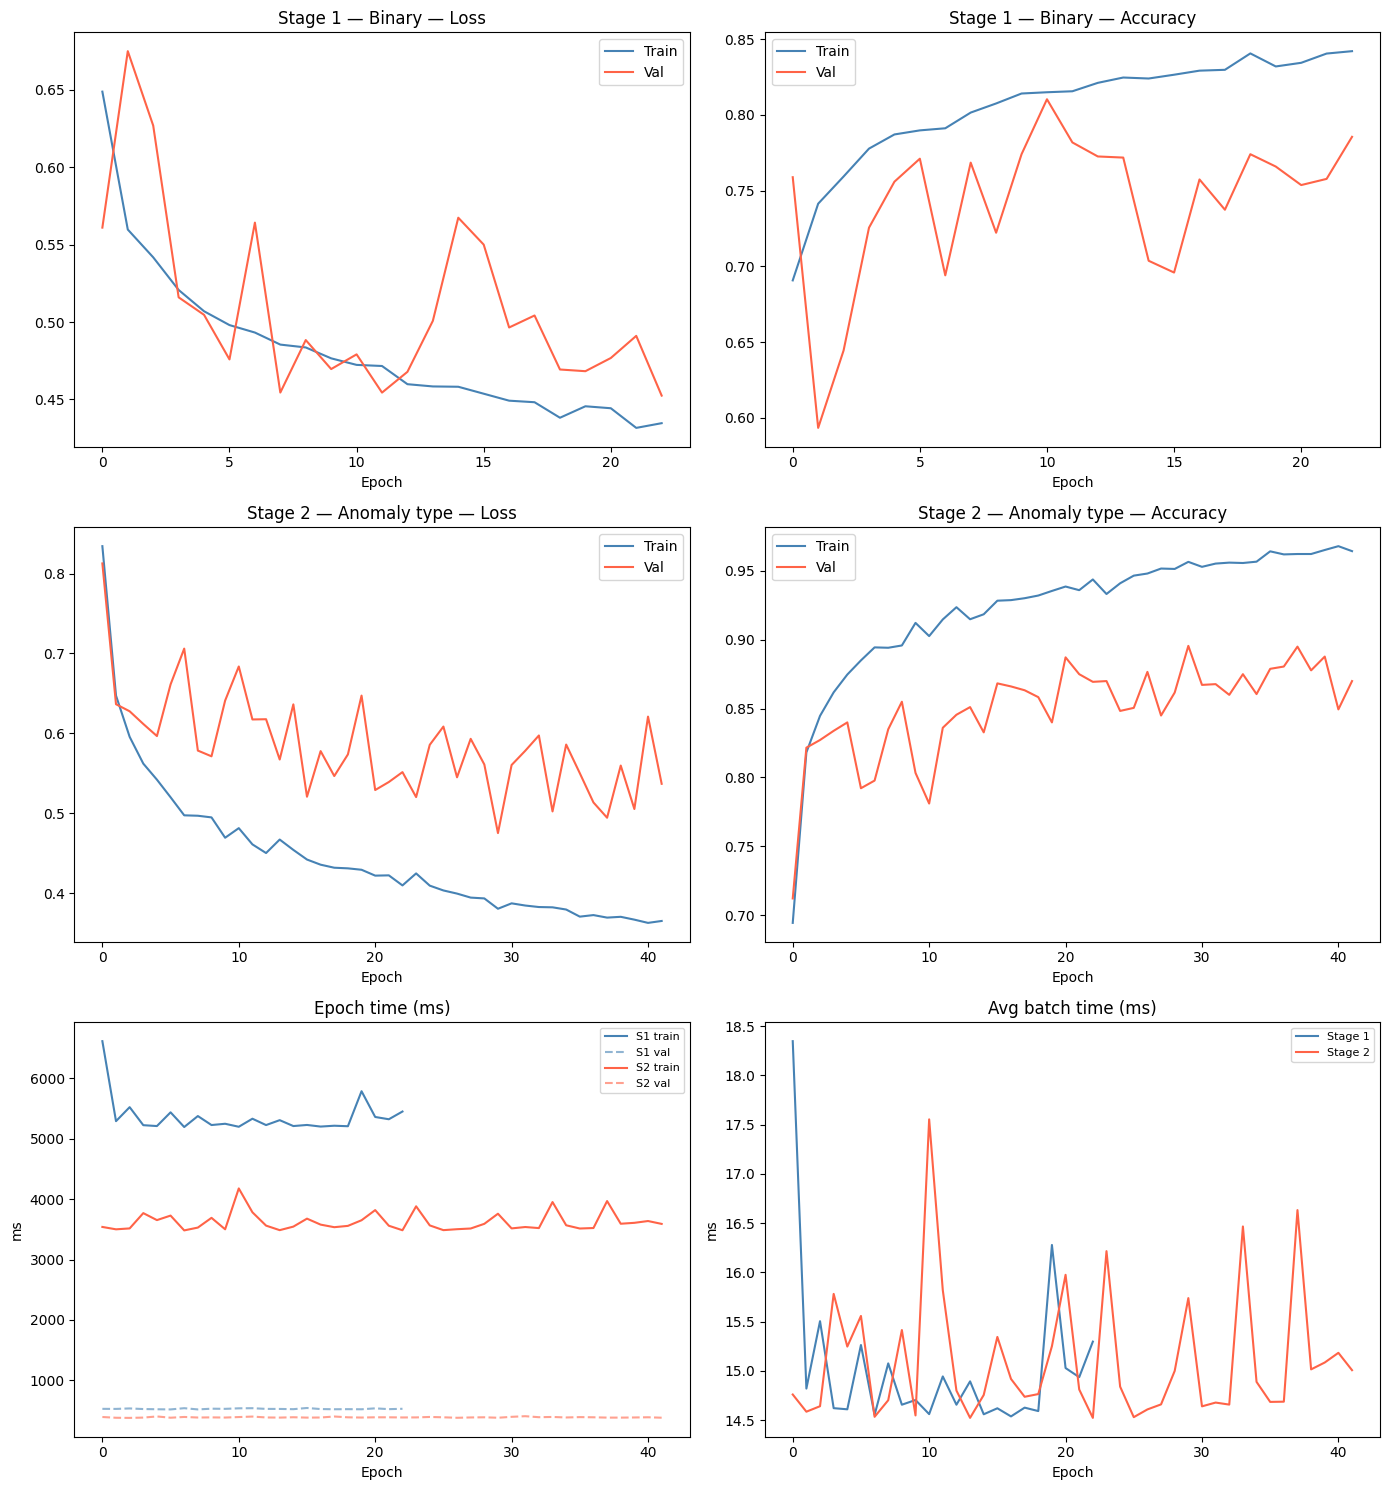

[INFO] Training curves → /content/drive/Shareddrives/DAEN Capstone/Models/training_curves.png

═══════════════════════════════════════════════════════
STAGE 1 — Binary detector (patch level)
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

 not_anomaly       0.90      0.81      0.85      1814
     anomaly       0.68      0.81      0.74       886

    accuracy                           0.81      2700
   macro avg       0.79      0.81      0.79      2700
weighted avg       0.83      0.81      0.81      2700



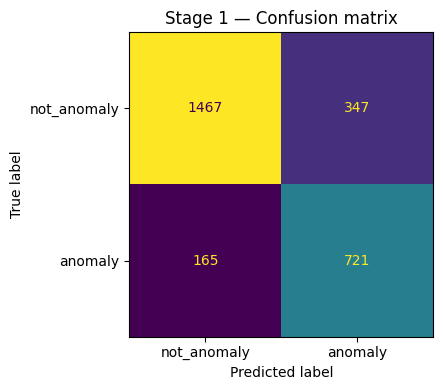


═══════════════════════════════════════════════════════
STAGE 2 — Anomaly classifier (patch level)
═══════════════════════════════════════════════════════
                precision    recall  f1-score   support

  cube_anomaly       0.93      0.82      0.87       750
sphere_anomaly       0.95      0.95      0.95       749
  boat_anomaly       0.72      0.93      0.81       300

      accuracy                           0.90      1799
     macro avg       0.87      0.90      0.88      1799
  weighted avg       0.91      0.90      0.90      1799



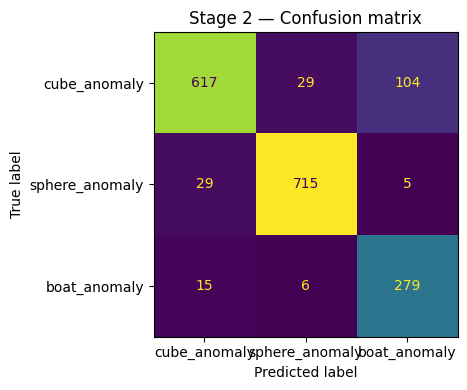


[STAGE 5/5] End-to-end cluster inference on val scenes …


Inference: 100%|██████████| 24/24 [00:19<00:00,  1.22it/s]



[PIPELINE RESULTS] 429 clusters
   ID              True        Final pred     S1     S2   Points  OK
  ──────────────────────────────────────────────────────────────────────
    0       not_anomaly       not_anomaly   0.59      -      190  ✓
    1       not_anomaly       not_anomaly   0.92      -      355  ✓
    2       not_anomaly       not_anomaly   0.98      -      356  ✓
    3       not_anomaly    sphere_anomaly   0.59   0.76    1,107  ✗
    4       not_anomaly       not_anomaly   0.92      -   33,677  ✓
    5       not_anomaly       not_anomaly   0.96      -      241  ✓
    6       not_anomaly       not_anomaly   0.92      -    2,660  ✓
    7       not_anomaly       not_anomaly   0.89      -   13,402  ✓
    8      cube_anomaly       not_anomaly   0.61      -    3,234  ✗
    9       not_anomaly       not_anomaly   0.94      -    2,261  ✓
   10       not_anomaly       not_anomaly   0.93      -   44,706  ✓
   11       not_anomaly       not_anomaly   0.92      -    1,080  ✓
   12    

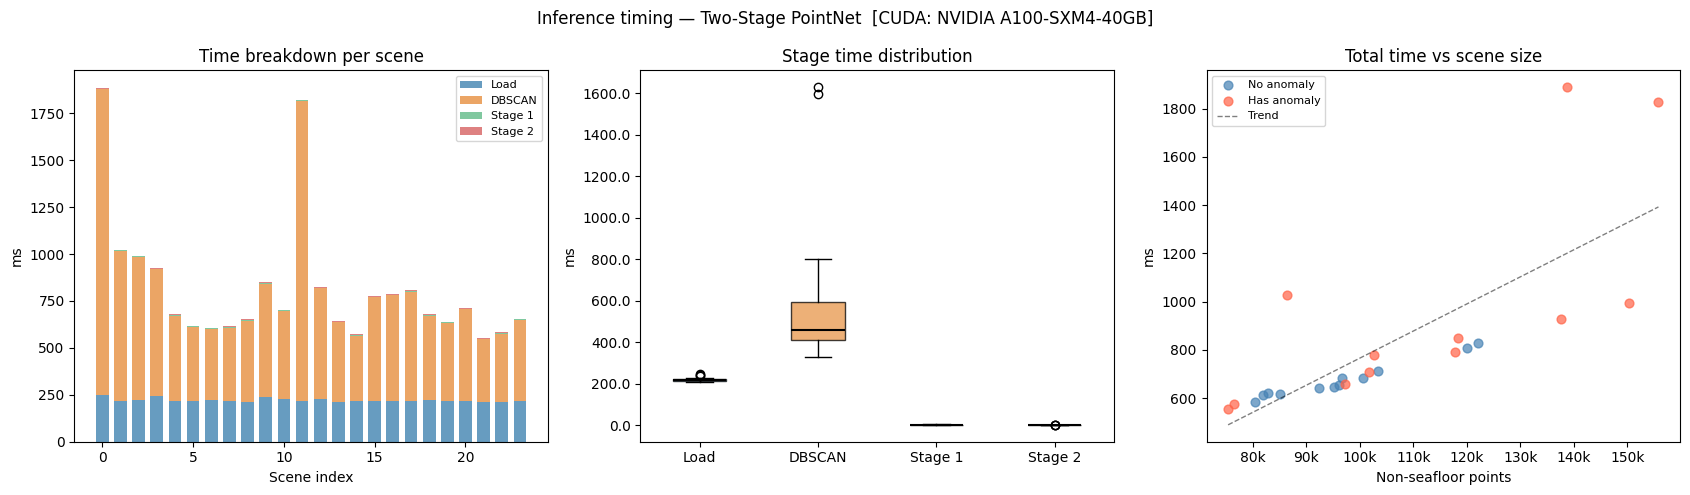

[INFO] Timing plots → /content/drive/Shareddrives/DAEN Capstone/Models/inference_timing.png
[INFO] Timing CSV   → /content/drive/Shareddrives/DAEN Capstone/Models/inference_timing.csv

✅ Done! Outputs saved to: /content/drive/Shareddrives/DAEN Capstone/Models

Visualise any scene:
  visualise_scene(0, model1, model2, mode='pipeline')
  visualise_scene(0, model1, model2, mode='objects')   ← most detail
  visualise_scene(0, model1, model2, mode='comparison')
  visualise_scene(0, model1, model2, mode='stage1')    ← binary only


In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
# CELL 15: RUN EVERYTHING
# ═════════════════════════════════════════════════════════════════════════════

pipeline_start = time.perf_counter()

# 1. Discover + split scenes
scenes = discover_scenes(DATA_DIR)
train_scenes, val_scenes = train_test_split(
    scenes, test_size=TEST_SIZE,
    stratify=[s["has_anomaly"] for s in scenes],
    random_state=RANDOM_SEED)
print(f"[INFO] Train: {len(train_scenes)} | Val: {len(val_scenes)} scenes")

# 2. Extract patches — timed
print("\n[STAGE 1/5] Extracting patches …")
tr1, tr2, va1, va2 = [], [], [], []
t_patch_start = time.perf_counter()

for split, patch_list1, patch_list2 in [
        (train_scenes, tr1, tr2),
        (val_scenes,   va1, va2)]:
    label = "Train" if patch_list1 is tr1 else "Val"
    for scene in tqdm(split, desc=label):
        try:
            df = load_non_seafloor(scene)
            if df is not None:
                patch_list1.extend(extract_patches_stage1(df))
                patch_list2.extend(extract_patches_stage2(df))
        except Exception as e:
            print(f"[WARN] {scene['path'].name}: {e}")

t_patch_s = time.perf_counter() - t_patch_start
print(f"\n  Stage 1 — Train: {len(tr1):,} | Val: {len(va1):,} patches")
print(f"  Stage 2 — Train: {len(tr2):,} | Val: {len(va2):,} patches")
print(f"  Patch extraction time: {t_patch_s:.1f}s")

# 3. Train Stage 1 — timing built into train_stage
print("\n[STAGE 2/5] Training Stage 1 — Binary detector …")
t_s1_train_start = time.perf_counter()
model1   = PointNet(num_classes=2).to(DEVICE)
history1 = train_stage(model1, tr1, va1, n_classes=2,
                        stage_name="Stage 1",
                        ckpt_path=f"{OUTPUT_DIR}/stage1_binary.pt")
t_s1_train_s = time.perf_counter() - t_s1_train_start

# 4. Train Stage 2 — timing built into train_stage
print("\n[STAGE 3/5] Training Stage 2 — Anomaly classifier …")
t_s2_train_start = time.perf_counter()
model2   = PointNet(num_classes=NUM_ANOMALY_CLS).to(DEVICE)
history2 = train_stage(model2, tr2, va2, n_classes=NUM_ANOMALY_CLS,
                        stage_name="Stage 2",
                        ckpt_path=f"{OUTPUT_DIR}/stage2_classifier.pt")
t_s2_train_s = time.perf_counter() - t_s2_train_start

# 5. Plot training curves + evaluate patches
print("\n[STAGE 4/5] Evaluating …")
plot_training(history1, history2)
evaluate_stage1(model1, va1)
evaluate_stage2(model2, va2)

# 6. End-to-end cluster inference on val scenes — timed per scene
print("\n[STAGE 5/5] End-to-end cluster inference on val scenes …")
_warmup(model1, model2)

all_results  = []
scene_timings = []

for scene in tqdm(val_scenes, desc="Inference"):
    try:
        t_scene_start = time.perf_counter()

        with CUDATimer() as t_load:
            df = load_non_seafloor(scene)

        if df is None:
            continue

        with CUDATimer() as t_clust:
            clusters = extract_clusters(df)

        if not clusters:
            continue

        results, model_timing = run_pipeline(clusters, model1, model2)
        all_results.extend(results)

        t_scene_ms = (time.perf_counter() - t_scene_start) * 1000
        scene_timings.append({
            "scene":            scene["path"].stem,
            "has_anomaly":      scene["has_anomaly"],
            "n_points":         len(df),
            "n_clusters":       model_timing["n_clusters"],
            "n_anom_clusters":  model_timing["n_anomaly_clusters"],
            "t_load_ms":        t_load.ms,
            "t_cluster_ms":     t_clust.ms,
            "t_stage1_ms":      model_timing["t_stage1_ms"],
            "t_stage2_ms":      model_timing["t_stage2_ms"],
            "t_model_ms":       model_timing["t_model_ms"],
            "t_total_ms":       t_scene_ms,
        })
    except Exception as e:
        print(f"[WARN] {scene['path'].name}: {e}")

print_pipeline_summary(all_results)

# 7. Save models
save_models(model1, model2)

# ── Print full timing report ──────────────────────────────────────────────────
t_total_pipeline = time.perf_counter() - pipeline_start
timing_df = pd.DataFrame(scene_timings)
timing_df.to_csv(f"{OUTPUT_DIR}/inference_timing.csv", index=False)

print("\n" + "═"*62)
print("FULL PIPELINE TIMING REPORT")
print(f"Device: {DEVICE}" +
      (f"  |  GPU: {torch.cuda.get_device_name(0)}"
       if DEVICE.type == "cuda" else ""))
print("─"*62)
print(f"  Patch extraction          : {t_patch_s:>8.1f}s")
print(f"  Stage 1 training (total)  : {t_s1_train_s:>8.1f}s  "
      f"({len(history1['epoch_train_ms'])} epochs)")
print(f"  Stage 2 training (total)  : {t_s2_train_s:>8.1f}s  "
      f"({len(history2['epoch_train_ms'])} epochs)")
print(f"  Total pipeline wall time  : {t_total_pipeline:>8.1f}s")
print("─"*62)

if len(timing_df) > 0:
    print(f"\n  Per-scene inference (median over {len(timing_df)} val scenes):")
    cols = {
        "t_load_ms":    "  Load + filter",
        "t_cluster_ms": "  DBSCAN cluster",
        "t_stage1_ms":  "  Stage 1 forward",
        "t_stage2_ms":  "  Stage 2 forward",
        "t_model_ms":   "  Model total (S1+S2)",
        "t_total_ms":   "  End-to-end / scene",
    }
    total_med = timing_df["t_total_ms"].median()
    for col, label in cols.items():
        med = timing_df[col].median()
        std = timing_df[col].std()
        pct = 100 * med / total_med if total_med > 0 else 0
        print(f"  {label:<22}: {med:>8.2f}ms  ±{std:>6.2f}ms  "
              f"({pct:>4.1f}%)")

    pts_sec = (timing_df["n_points"] /
               (timing_df["t_total_ms"] / 1000)).median()
    print(f"\n  Throughput : {pts_sec:>10,.0f} points/sec")
    print(f"  Scenes/sec : {1000/total_med:>10.2f}")
    print("═"*62)

    # ── Timing visualisation ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle(
        f"Inference timing — Two-Stage PointNet  "
        f"[{DEVICE.type.upper()}"
        f"{': ' + torch.cuda.get_device_name(0) if DEVICE.type=='cuda' else ''}]",
        fontsize=12)

    stage_cols   = ["t_load_ms","t_cluster_ms","t_stage1_ms","t_stage2_ms"]
    stage_labels = ["Load","DBSCAN","Stage 1","Stage 2"]
    colours      = ["#4C8BB5","#E8964A","#6ABF8E","#D96B6B"]

    # Stacked bar per scene
    x      = np.arange(len(timing_df))
    bottom = np.zeros(len(timing_df))
    for col, lbl, col_c in zip(stage_cols, stage_labels, colours):
        vals = timing_df[col].values
        axes[0].bar(x, vals, bottom=bottom, label=lbl,
                     color=col_c, alpha=0.85, width=0.7)
        bottom += vals
    axes[0].set_title("Time breakdown per scene")
    axes[0].set_xlabel("Scene index"); axes[0].set_ylabel("ms")
    axes[0].legend(fontsize=8)

    # Boxplot per stage
    bp = axes[1].boxplot(
        [timing_df[c].values for c in stage_cols],
        labels=stage_labels, patch_artist=True,
        medianprops=dict(color="black", linewidth=1.5))
    for patch, col_c in zip(bp["boxes"], colours):
        patch.set_facecolor(col_c); patch.set_alpha(0.75)
    axes[1].set_title("Stage time distribution")
    axes[1].set_ylabel("ms")
    axes[1].yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))

    # Total time vs n_points
    anom_m = timing_df["has_anomaly"].astype(bool)
    axes[2].scatter(timing_df.loc[~anom_m,"n_points"],
                     timing_df.loc[~anom_m,"t_total_ms"],
                     c="steelblue", s=40, alpha=0.7, label="No anomaly")
    axes[2].scatter(timing_df.loc[anom_m,"n_points"],
                     timing_df.loc[anom_m,"t_total_ms"],
                     c="tomato", s=40, alpha=0.7, label="Has anomaly")
    if len(timing_df) > 2:
        z  = np.polyfit(timing_df["n_points"], timing_df["t_total_ms"], 1)
        xs = np.linspace(timing_df["n_points"].min(),
                          timing_df["n_points"].max(), 100)
        axes[2].plot(xs, np.poly1d(z)(xs), "k--", linewidth=1,
                      alpha=0.5, label="Trend")
    axes[2].set_title("Total time vs scene size")
    axes[2].set_xlabel("Non-seafloor points"); axes[2].set_ylabel("ms")
    axes[2].legend(fontsize=8)
    axes[2].xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda v,_: f"{v/1000:.0f}k"))

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/inference_timing.png", dpi=150,
                bbox_inches="tight")
    plt.show()
    print(f"[INFO] Timing plots → {OUTPUT_DIR}/inference_timing.png")
    print(f"[INFO] Timing CSV   → {OUTPUT_DIR}/inference_timing.csv")

print(f"\n✅ Done! Outputs saved to: {OUTPUT_DIR}")
print("\nVisualise any scene:")
print("  visualise_scene(0, model1, model2, mode='pipeline')")
print("  visualise_scene(0, model1, model2, mode='objects')   ← most detail")
print("  visualise_scene(0, model1, model2, mode='comparison')")
print("  visualise_scene(0, model1, model2, mode='stage1')    ← binary only")